## Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert, find_peaks, periodogram
from scipy.optimize import curve_fit
from scipy.fft import fft, fftfreq
from copy import deepcopy
from pathlib import Path


### The plot defaults
from matplotlib import rc

rc('legend', fontsize=13)


path_w = Path('/Users/alexander/Documents/projects/NetKet/Hubbard/measurement')
### Replace by path to latex
#os.environ["PATH"] += os.pathsep + "/Users/alexander/Documents/Package_lib/texlive/2021/bin/universal-darwin/"

#rc('font', size=14, **{'family': 'serif', 'serif': ['Computer Modern']})
#rc('text', usetex=True)
#rc('text.latex', preamble=r'\usepackage{lmodern}')

## parameters


In [2]:
L=4
Ne=14
U=8
iter=100

## $N(x,y)$

[[0.90185547 0.8170166  0.90637207 0.92773438]
 [0.87329102 0.73742676 0.88708496 0.95874023]
 [0.72070312 0.79077148 0.90515137 0.88061523]
 [0.90270996 0.90246582 0.95605469 0.93200684]]


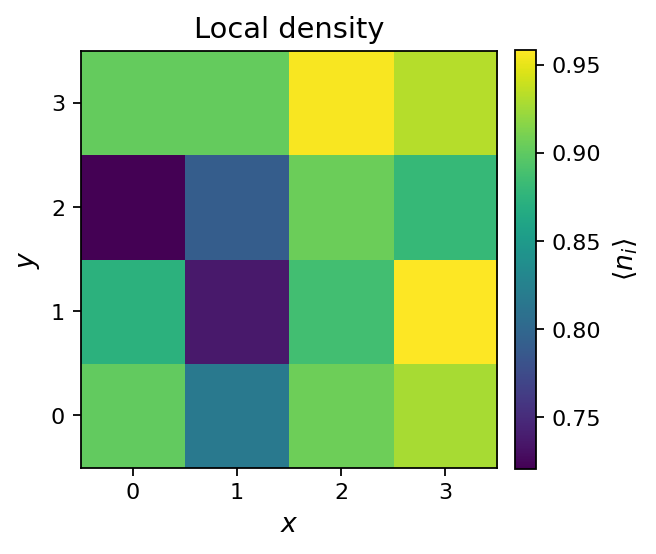

In [ ]:
fname = path_w / 'N_U={U:.3f}_L={L:d}_Ne={Ne:d}_iter={iter}.txt'.format(L=L,U=U,Ne=Ne,iter=iter)

# load flat data
N = np.loadtxt(fname)

# reshape to 2D
density = N.reshape(L, L)

print(density)

fig, ax = plt.subplots(figsize=(4.2, 4.0), dpi=160)

im = ax.imshow(
    density,
    origin='lower',
    interpolation='nearest',
    aspect='equal'   
)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(r'$\langle n_i \rangle$', fontsize=12)

ax.set_xlabel(r'$x$', fontsize=12)
ax.set_ylabel(r'$y$', fontsize=12)
ax.set_title(r'Local density', fontsize=13)

ax.set_xticks(range(L))
ax.set_yticks(range(L))
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

## $\langle N(x,y)N(0,0) \rangle$

In [ ]:
fname = path_w / 'NN_U={U:.3f}_L={L:d}_Ne={Ne:d}_iter={iter}.txt'.format(L=L,U=U,Ne=Ne,iter=iter)
# load flat data
NN = np.loadtxt(fname)

# reshape to 2D
density = NN.reshape(L*L, L*L)



print(density[0])
print(density[1])

[ 0.08875632 -0.01197737 -0.00503868 -0.00465107 -0.00755298 -0.01392931
 -0.00632125 -0.00148594 -0.01129818 -0.00368893 -0.00247294 -0.00573552
 -0.00503188 -0.00285858 -0.00235987 -0.00435382]
[-0.01197737  0.1502329  -0.01383646 -0.00699782 -0.00450888 -0.03974576
 -0.01748775 -0.0036436  -0.0045979  -0.00850019 -0.00588112 -0.00145969
 -0.00669406 -0.01210983 -0.00547779 -0.00731467]


## n(k)